# 06 - Multi-stage Core Formation & Differentiation

This notebook simulates the multi-stage metal–silicate differentiation of growing planets using impact event histories and early embryo compositions.

It covers:
- Loading early embryo bulk compositions from `03_embryo_bulk_composition.csv`
- Loading classified impact event histories from `05_impact_events.xlsx`
- For each impact event (small / global / partial), computing re-equilibrating and non-re-equilibrating bulk compositions
- Solving metal–silicate equilibrium using `KDCalculator` + `ForwardKDOSolver`
- Updating target planet composition after each collision
- Visualizing final planet compositions (mantle + core) normalized to Mg and CI chondrites
- Exporting differentiation history to Excel

> **Prerequisites:** Run `01` → `05` notebooks first.  
> **Input:** `./Tables/03_embryo_bulk_composition.csv` + `./Tables/05_impact_events.xlsx`  
> **Output:** `./Tables/06_differentiation.xlsx`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.patches as mpatches
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
})

print("Setup complete.")

Setup complete.


## 1. Load Input Data

Load early embryo bulk compositions and the classified impact event histories.

- **Early compositions** (`03_embryo_bulk_composition.csv`): bulk mass fractions of major elements for all embryos at t = 5 Myr
- **Impact events** (`05_impact_events.xlsx`): classified collision records with P/T equilibration conditions for each planet

In [2]:
# ── Load early embryo compositions ──────────────────────
path_com = './Tables/03_embryo_bulk_composition.csv'
early_components = pd.read_csv(path_com, index_col=0)

# ── Load impact event histories ──────────────────────────
path_impact = './Tables/05_impact_events.xlsx'
impact_dict = pd.read_excel(path_impact, sheet_name=None)

print(f"Early compositions : {early_components.shape}")
print(f"Planets (sheets)   : {list(impact_dict.keys())}")
early_components.head()

Early compositions : (1244, 25)
Planets (sheets)   : ['planets_1', 'planets_2', 'planets_3']


,i,a,e,inc,m_e,EF,EC,OC,CI,EF_ratio,...,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,6170,1.885426,0.055145,0.026060,0.000215,0.0,0.0,0.000215,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170354,0.000206,0.372605,0.062612,0.012337,9.363221e-06,0.004309
1,5974,1.328577,0.136199,0.125076,0.000367,0.0,0.0,0.000367,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170369,0.000207,0.372605,0.062596,0.012336,9.341574e-06,0.004292
2,5069,2.733346,0.174028,0.035980,0.000396,0.0,0.0,0.000000,0.000396,0.0,...,0.338081,0.013408,0.019577,0.280679,0.004247,0.328082,0.004619,0.011308,4.364732e-08,0.015927
3,6279,2.010899,0.110985,0.049694,0.000401,0.0,0.0,0.000401,0.000000,0.0,...,0.350476,0.012646,0.018756,0.170373,0.000208,0.372605,0.062593,0.012335,9.336684e-06,0.004288
4,5550,2.865501,0.364656,0.360332,0.000402,0.0,0.0,0.000000,0.000402,0.0,...,0.338081,0.013408,0.019577,0.280680,0.004249,0.328082,0.004618,0.011306,4.362293e-08,0.015923


## 2. Define Major Element Columns

Major elements tracked through differentiation:

| Phase  | Elements |
|--------|----------|
| Mantle | MgO, Al₂O₃, CaO, FeO, NiO, SiO₂ |
| Core   | Fe, Ni, Si, O |

In [3]:
major_elements = [
    'i', 'm_e',
    'MgO', 'Al2O3', 'CaO',
    'FeO', 'NiO', 'SiO2',
    'Fe', 'Ni', 'Si', 'O',
]
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items   = ['Fe', 'Ni', 'Si', 'O']
col_list     = [c for c in major_elements if c not in ('i', 'm_e')]

print(f"Mantle items : {mantle_items}")
print(f"Core items   : {core_items}")

Mantle items : ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
Core items   : ['Fe', 'Ni', 'Si', 'O']


## 3. Multi-stage Differentiation Solver

For each impact event, compute the re-equilibrating (`bulk_re_eq`) and non-re-equilibrating (`bulk_no_re_eq`) bulk compositions based on event type:

| Event | Re-equilibrating fraction | Notes |
|-------|--------------------------|-------|
| `small` | Impactor mantle + f_core_pl × impactor core | Target not fully molten |
| `global` | Impactor + k_mantle × f_mantle × target mantle | magma ocean |
| `partial` | Impactor + k_mantle × target mantle | Partial melt pool |

Then solve for metal–silicate equilibrium using `KDCalculator` + `ForwardKDOSolver`,  
and update the target composition after each event.

In [4]:
df_dict = {}

for key in impact_dict.keys():
    df = impact_dict[key]

    # ── Build filtered component table for all involved particles ──
    id_set            = set(df['target_id'].unique()) | set(df['impactor_id'].unique())
    filtered_comp     = (
        early_components[early_components['i'].isin(id_set)][major_elements]
        .copy()
        .set_index('i')
    )

    df_var = pd.DataFrame(columns=['Time', 'target_id'] + col_list)

    for num in df.index:
        t            = df.loc[num, 'Time']
        P_equil      = df.loc[num, 'P_equil']
        T_equil      = df.loc[num, 'T_equil']
        target_id    = df.loc[num, 'target_id']
        impactor_id  = df.loc[num, 'impactor_id']
        event        = df.loc[num, 'events']

        # ── KD coefficients ──────────────────────────────
        kd_calc = ad.KDCalculator()
        KD_Ni   = kd_calc.get_KD('Ni', P_equil, T_equil)
        KD_Si   = kd_calc.get_KD('Si', P_equil, T_equil)
        KD_O    = kd_calc.get_KD('O',  P_equil, T_equil)

        target_comp   = filtered_comp[filtered_comp.index == target_id].copy()
        impactor_comp = filtered_comp[filtered_comp.index == impactor_id].copy()
        mass_target   = target_comp['m_e'].values[0]
        mass_impactor = impactor_comp['m_e'].values[0]
        total_mass    = mass_target + mass_impactor

        # ── Bulk partitioning by event type ──────────────
        if event == 'small':
            f_core_pl = 0.7
            bulk_no_re_eq = {
                'MgO'  : target_comp['MgO'].values[0]   * mass_target,
                'Al2O3': target_comp['Al2O3'].values[0] * mass_target,
                'CaO'  : target_comp['CaO'].values[0]   * mass_target,
                'FeO'  : target_comp['FeO'].values[0]   * mass_target,
                'NiO'  : target_comp['NiO'].values[0]   * mass_target,
                'SiO2' : target_comp['SiO2'].values[0]  * mass_target,
                'Fe'   : target_comp['Fe'].values[0]    * mass_target + impactor_comp['Fe'].values[0] * mass_impactor * (1 - f_core_pl),
                'Ni'   : target_comp['Ni'].values[0]    * mass_target + impactor_comp['Ni'].values[0] * mass_impactor * (1 - f_core_pl),
                'Si'   : target_comp['Si'].values[0]    * mass_target + impactor_comp['Si'].values[0] * mass_impactor * (1 - f_core_pl),
                'O'    : target_comp['O'].values[0]     * mass_target + impactor_comp['O'].values[0]  * mass_impactor * (1 - f_core_pl),
            }
            bulk_re_eq = {
                'MgO'  : impactor_comp['MgO'].values[0]   * mass_impactor,
                'Al2O3': impactor_comp['Al2O3'].values[0] * mass_impactor,
                'CaO'  : impactor_comp['CaO'].values[0]   * mass_impactor,
                'FeO'  : impactor_comp['FeO'].values[0]   * mass_impactor,
                'NiO'  : impactor_comp['NiO'].values[0]   * mass_impactor,
                'SiO2' : impactor_comp['SiO2'].values[0]  * mass_impactor,
                'Fe'   : impactor_comp['Fe'].values[0]    * mass_impactor * f_core_pl,
                'Ni'   : impactor_comp['Ni'].values[0]    * mass_impactor * f_core_pl,
                'Si'   : impactor_comp['Si'].values[0]    * mass_impactor * f_core_pl,
                'O'    : impactor_comp['O'].values[0]     * mass_impactor * f_core_pl,
            }

        elif event == 'global':
            k_mantle  = df.loc[num, 'k_mantle']
            f_mantle  = 0.05
            f_core_pl = 0.7
            bulk_no_re_eq = {
                'MgO'  : target_comp['MgO'].values[0]   * mass_target * (1 - k_mantle * f_mantle),
                'Al2O3': target_comp['Al2O3'].values[0] * mass_target * (1 - k_mantle * f_mantle),
                'CaO'  : target_comp['CaO'].values[0]   * mass_target * (1 - k_mantle * f_mantle),
                'FeO'  : target_comp['FeO'].values[0]   * mass_target * (1 - k_mantle * f_mantle),
                'NiO'  : target_comp['NiO'].values[0]   * mass_target * (1 - k_mantle * f_mantle),
                'SiO2' : target_comp['SiO2'].values[0]  * mass_target * (1 - k_mantle * f_mantle),
                'Fe'   : target_comp['Fe'].values[0]    * mass_target + impactor_comp['Fe'].values[0] * mass_impactor * (1 - f_core_pl),
                'Ni'   : target_comp['Ni'].values[0]    * mass_target + impactor_comp['Ni'].values[0] * mass_impactor * (1 - f_core_pl),
                'Si'   : target_comp['Si'].values[0]    * mass_target + impactor_comp['Si'].values[0] * mass_impactor * (1 - f_core_pl),
                'O'    : target_comp['O'].values[0]     * mass_target + impactor_comp['O'].values[0]  * mass_impactor * (1 - f_core_pl),
            }
            bulk_re_eq = {
                'MgO'  : impactor_comp['MgO'].values[0]   * mass_impactor + target_comp['MgO'].values[0]   * mass_target * k_mantle * f_mantle,
                'Al2O3': impactor_comp['Al2O3'].values[0] * mass_impactor + target_comp['Al2O3'].values[0] * mass_target * k_mantle * f_mantle,
                'CaO'  : impactor_comp['CaO'].values[0]   * mass_impactor + target_comp['CaO'].values[0]   * mass_target * k_mantle * f_mantle,
                'FeO'  : impactor_comp['FeO'].values[0]   * mass_impactor + target_comp['FeO'].values[0]   * mass_target * k_mantle * f_mantle,
                'NiO'  : impactor_comp['NiO'].values[0]   * mass_impactor + target_comp['NiO'].values[0]   * mass_target * k_mantle * f_mantle,
                'SiO2' : impactor_comp['SiO2'].values[0]  * mass_impactor + target_comp['SiO2'].values[0]  * mass_target * k_mantle * f_mantle,
                'Fe'   : impactor_comp['Fe'].values[0]    * mass_impactor * f_core_pl,
                'Ni'   : impactor_comp['Ni'].values[0]    * mass_impactor * f_core_pl,
                'Si'   : impactor_comp['Si'].values[0]    * mass_impactor * f_core_pl,
                'O'    : impactor_comp['O'].values[0]     * mass_impactor * f_core_pl,
            }

        elif event == 'partial':
            k_mantle = df.loc[num, 'k_mantle']
            f_core   = 0.3
            bulk_no_re_eq = {
                'MgO'  : target_comp['MgO'].values[0]   * mass_target * (1 - k_mantle),
                'Al2O3': target_comp['Al2O3'].values[0] * mass_target * (1 - k_mantle),
                'CaO'  : target_comp['CaO'].values[0]   * mass_target * (1 - k_mantle),
                'FeO'  : target_comp['FeO'].values[0]   * mass_target * (1 - k_mantle),
                'NiO'  : target_comp['NiO'].values[0]   * mass_target * (1 - k_mantle),
                'SiO2' : target_comp['SiO2'].values[0]  * mass_target * (1 - k_mantle),
                'Fe'   : target_comp['Fe'].values[0]    * mass_target + impactor_comp['Fe'].values[0] * mass_impactor * (1 - f_core),
                'Ni'   : target_comp['Ni'].values[0]    * mass_target + impactor_comp['Ni'].values[0] * mass_impactor * (1 - f_core),
                'Si'   : target_comp['Si'].values[0]    * mass_target + impactor_comp['Si'].values[0] * mass_impactor * (1 - f_core),
                'O'    : target_comp['O'].values[0]     * mass_target + impactor_comp['O'].values[0]  * mass_impactor * (1 - f_core),
            }
            bulk_re_eq = {
                'MgO'  : impactor_comp['MgO'].values[0]   * mass_impactor + target_comp['MgO'].values[0]   * mass_target * k_mantle,
                'Al2O3': impactor_comp['Al2O3'].values[0] * mass_impactor + target_comp['Al2O3'].values[0] * mass_target * k_mantle,
                'CaO'  : impactor_comp['CaO'].values[0]   * mass_impactor + target_comp['CaO'].values[0]   * mass_target * k_mantle,
                'FeO'  : impactor_comp['FeO'].values[0]   * mass_impactor + target_comp['FeO'].values[0]   * mass_target * k_mantle,
                'NiO'  : impactor_comp['NiO'].values[0]   * mass_impactor + target_comp['NiO'].values[0]   * mass_target * k_mantle,
                'SiO2' : impactor_comp['SiO2'].values[0]  * mass_impactor + target_comp['SiO2'].values[0]  * mass_target * k_mantle,
                'Fe'   : impactor_comp['Fe'].values[0]    * mass_impactor * f_core,
                'Ni'   : impactor_comp['Ni'].values[0]    * mass_impactor * f_core,
                'Si'   : impactor_comp['Si'].values[0]    * mass_impactor * f_core,
                'O'    : impactor_comp['O'].values[0]     * mass_impactor * f_core,
            }

        # ── Build solver parameters ───────────────────────
        params_dict = {
            'Fe_t'  : bulk_re_eq['FeO'] + bulk_re_eq['Fe'],
            'Ni_t'  : bulk_re_eq['NiO'] + bulk_re_eq['Ni'],
            'Si_t'  : bulk_re_eq['SiO2'] + bulk_re_eq['Si'],
            'O_L'   : bulk_re_eq['Fe'] + bulk_re_eq['Ni'] + 2 * bulk_re_eq['Si'] - bulk_re_eq['O'],
            'KD_Ni' : KD_Ni,
            'KD_Si' : KD_Si,
            'u'     : bulk_re_eq['MgO'],
            'm'     : 2 * bulk_re_eq['Al2O3'],
            'n'     : bulk_re_eq['CaO'],
        }

        p0     = ad.KD_Params(**params_dict)
        solver = ad.ForwardKDOSolver(
            p0,
            nonneg='clip',
            enforce_z_box=True,
            enforce_d_nonneg=True,
        )
        res      = solver.solve_x_for_KD_O(KD_O, tol=1e-12, max_iter=300, grid_N=400)
        res_dict = vars(res)

        # ── Update target composition ─────────────────────
        bulk = {
            'm_e'  : total_mass,
            'MgO'  : (bulk_no_re_eq['MgO']   + params_dict['u'])       / total_mass,
            'Al2O3': (bulk_no_re_eq['Al2O3'] + params_dict['m'] / 2)   / total_mass,
            'CaO'  : (bulk_no_re_eq['CaO']   + params_dict['n'])       / total_mass,
            'FeO'  : (bulk_no_re_eq['FeO']   + res_dict['x_'])         / total_mass,
            'NiO'  : (bulk_no_re_eq['NiO']   + res_dict['y_'])         / total_mass,
            'SiO2' : (bulk_no_re_eq['SiO2']  + res_dict['z_'])         / total_mass,
            'Fe'   : (bulk_no_re_eq['Fe']    + res_dict['a_'])         / total_mass,
            'Ni'   : (bulk_no_re_eq['Ni']    + res_dict['b_'])         / total_mass,
            'Si'   : (bulk_no_re_eq['Si']    + res_dict['c_'])         / total_mass,
            'O'    : (bulk_no_re_eq['O']     + res_dict['d_'])         / total_mass,
        }

        for k, v in bulk.items():
            filtered_comp.loc[target_id, k] = v

        df_var.loc[num, 'Time']      = t
        df_var.loc[num, 'target_id'] = target_id
        for k, v in bulk.items():
            df_var.loc[num, k] = v

    df_dict[key] = df_var
    print(f"Processed: {key}  ({len(df_var)} events)")

Processed: planets_1  (142 events)
Processed: planets_2  (96 events)
Processed: planets_3  (26 events)


## 4. Inspect Final Planet Compositions (t = 100 Myr)

Collect the last row of each planet's differentiation history as the final composition.

In [5]:
df_planets = pd.DataFrame()

for key, df in df_dict.items():
    if not df.empty:
        last_row = df.iloc[[-1]].copy()
        last_row = last_row[['Time', 'target_id', 'm_e'] + col_list]
        df_planets = pd.concat([df_planets, last_row], ignore_index=True)

print(f"Final planets: {len(df_planets)}")
df_planets

Final planets: 3


,Time,target_id,m_e,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O
0,96.532137,4189,0.841634,0.341963,0.014786,0.021506,0.05189,0.002088,0.300715,0.225989,0.013282,0.02778,0.017134
1,57.25302,2768,0.353523,0.343328,0.014508,0.021154,0.055605,0.000937,0.324785,0.216198,0.014045,0.009439,0.002809
2,53.386374,4755,0.081899,0.344231,0.013955,0.020417,0.075693,0.000437,0.342852,0.186905,0.013973,0.001538,0.001931


## 5. Visualize Bulk Composition (Mg-Normalized)

Plot raw mass fractions of mantle + core elements for each planet,  
normalized to MgO. Marker size scales with planet mass.

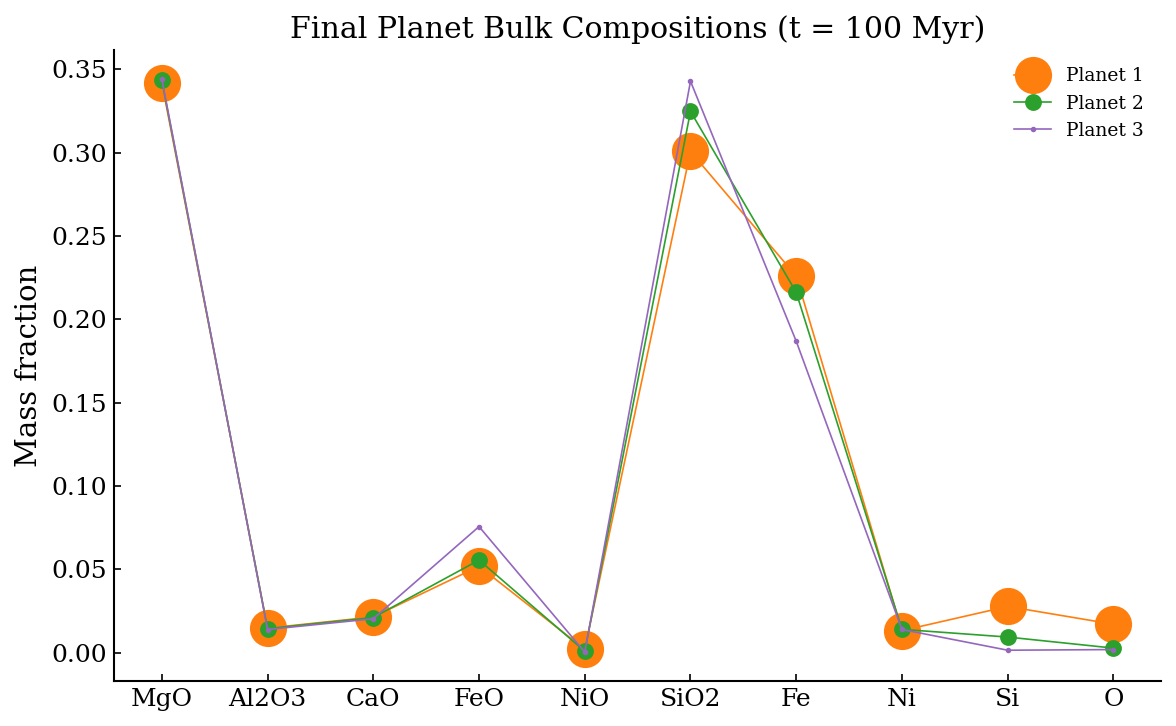

In [6]:
planet_ids = [f'Planet {i+1}' for i in range(len(df_planets))]
cmap       = plt.get_cmap('tab10')
excl_idx   = {0, 3}
color_idx  = [i for i in range(10) if i not in excl_idx]
colors     = [cmap(color_idx[i % len(color_idx)]) for i in range(len(df_planets))]

major_items = mantle_items + core_items

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(df_planets)):
    x = df_planets[major_items].iloc[i].index
    y = df_planets[major_items].iloc[i].values
    m = df_planets['m_e'].iloc[i]
    ax.plot(x, y, marker='o', linewidth=0.8, markersize=20 * m,
            label=planet_ids[i], color=colors[i])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Mass fraction')
ax.set_title('Final Planet Bulk Compositions (t = 100 Myr)')
ax.legend(fontsize=9, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

## 6. Normalize to Mg and CI Chondrites

Normalize all elements to Mg first, then to CI chondritic abundances.  
This allows direct comparison of planetary compositions to solar system building blocks.

In [7]:
# ── Mg normalization ─────────────────────────────────────
df_planets_Mg = df_planets[major_items].copy()
df_planets_Mg = df_planets_Mg.div(df_planets['MgO'].values, axis=0)

# ── CI normalization ──────────────────────────────────────
CI_bulk_mg    = ad.constants.CI_bulk_mg
df_CI         = pd.DataFrame([CI_bulk_mg])

df_planets_CI = df_planets_Mg[major_items[1:-1]].copy()
df_planets_CI[mantle_items[1:]] = df_planets_CI[mantle_items[1:]].div(
    df_CI[mantle_items[1:]].values[0]
)
df_planets_CI[core_items[:-1]] = df_planets_CI[core_items[:-1]].div(
    df_CI[mantle_items[3:]].values[0]
)

print("CI-normalized compositions:")
df_planets_CI

CI-normalized compositions:


,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si
0,1.090287,1.086059,0.179817,0.132718,0.906181,0.783122,0.844197,0.083714
1,1.06554,1.064072,0.191924,0.059339,0.974824,0.746215,0.889121,0.02833
2,1.022185,1.024271,0.260572,0.027607,1.026352,0.643418,0.882242,0.004603


## 7. Composition Spider Diagram (CI-normalized)

Scatter plot of Mg-normalized, CI-normalized element abundances for mantle (■) and core (●).  
- Y-axis: log scale
- Dashed line at 1.0 = CI chondritic value
- Marker size scales with planet mass

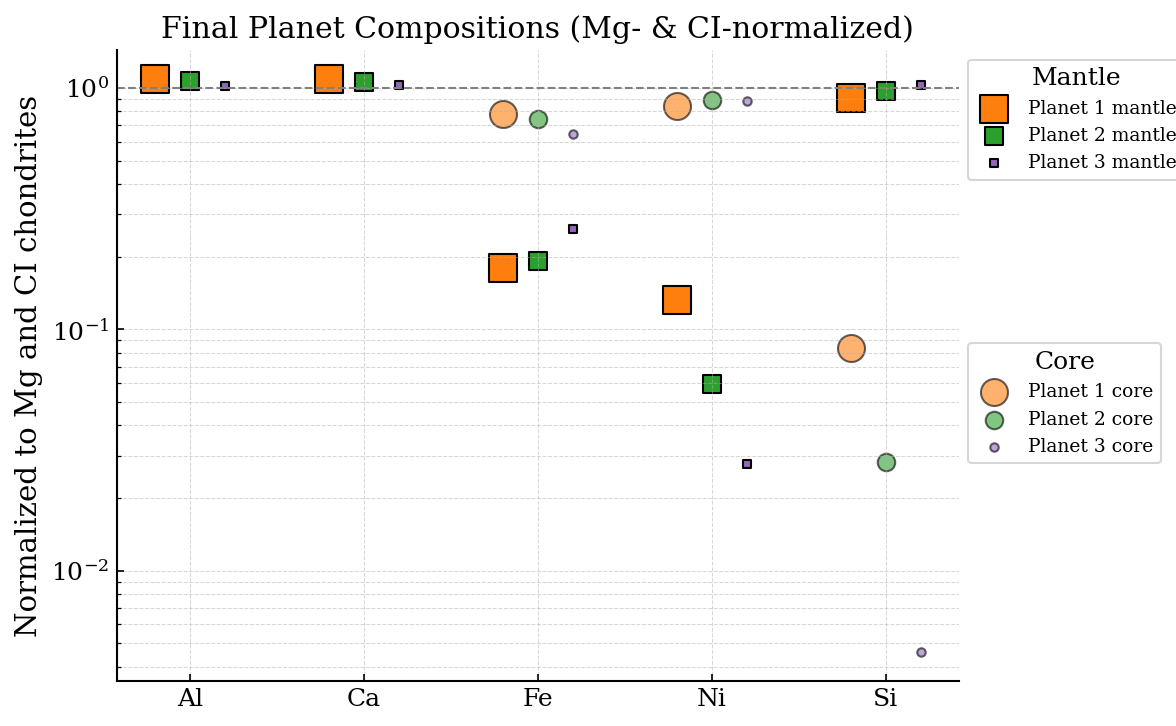

In [8]:
elements    = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
mantle_keys = ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_keys   = ['Fe', 'Ni', 'Si']
x_idx       = np.arange(len(elements))
xx_idx      = np.array([2, 3, 4])   # Fe, Ni, Si positions
offsets     = np.linspace(-0.2, 0.2, len(df_planets))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(df_planets)):
    m = df_planets['m_e'].iloc[i]
    ax.scatter(x_idx + offsets[i],
               df_planets_CI[mantle_keys].iloc[i].values,
               marker='s', s=200 * m,
               color=colors[i], edgecolor='k', alpha=1,
               label=f'{planet_ids[i]} mantle')
    ax.scatter(xx_idx + offsets[i],
               df_planets_CI[core_keys].iloc[i].values,
               marker='o', s=200 * m,
               color=colors[i], edgecolor='k', alpha=0.6,
               label=f'{planet_ids[i]} core')

ax.set_yscale('log')
ax.set_xticks(x_idx)
ax.set_xticklabels(elements, fontsize=12)
ax.set_ylabel('Normalized to Mg and CI chondrites')
ax.set_title('Final Planet Compositions (Mg- & CI-normalized)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
mantle_h = [(h, l) for h, l in zip(handles, labels) if 'mantle' in l]
core_h   = [(h, l) for h, l in zip(handles, labels) if 'core'   in l]

leg1 = ax.legend([h for h, _ in mantle_h], [l for _, l in mantle_h],
                 title='Mantle', bbox_to_anchor=(1.0, 1.0),
                 loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend([h for h, _ in core_h], [l for _, l in core_h],
          title='Core', bbox_to_anchor=(1.0, 0.55),
          loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Export Results

Save the full differentiation history (one sheet per planet) to Excel.

In [9]:
import pathlib

save_dir  = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

save_file = save_dir / '06_differentiation.xlsx'
with pd.ExcelWriter(save_file) as writer:
    for key, df in df_dict.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"Saved: {save_file}")

# Verify
df_check = pd.read_excel(save_file, sheet_name=None)
print(f"Sheets: {list(df_check.keys())}")

Saved: Tables/06_differentiation.xlsx
Sheets: ['planets_1', 'planets_2', 'planets_3']


## 9. Quick Inspection

Preview the differentiation history of the first planet.

In [10]:
df_p1 = df_check[list(df_check.keys())[0]]
print(f"Shape: {df_p1.shape}")
display(df_p1.head())
display(df_p1.tail())

Shape: (142, 13)


,Time,target_id,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O,m_e
0,4.930942,6604,0.350476,0.012646,0.018756,0.170452,0.000214,0.372605,0.062514,0.012329,0.000009,0.004203,0.002504
1,4.935332,6243,0.345569,0.015157,0.022087,0.024292,0.000015,0.322750,0.252498,0.015248,0.002383,0.001435,0.014268
2,4.937856,4189,0.341916,0.015269,0.022164,0.028875,0.000402,0.298470,0.255840,0.015384,0.021679,0.005618,0.309152
3,4.964972,6439,0.350476,0.012646,0.018756,0.170343,0.000202,0.372605,0.062622,0.012340,0.000009,0.004323,0.001991
4,5.019652,4189,0.341706,0.015213,0.022083,0.029019,0.000399,0.299802,0.255249,0.015363,0.021165,0.005541,0.318787


,Time,target_id,MgO,Al2O3,CaO,FeO,NiO,SiO2,Fe,Ni,Si,O,m_e
137,60.896827,6832,0.347747,0.012813,0.018937,0.197105,0.000512,0.362804,0.047382,0.012694,0.000006,0.004986,0.004275
138,61.048169,6832,0.348445,0.012771,0.018891,0.190280,0.000437,0.365313,0.051257,0.012599,0.000007,0.004786,0.005746
139,62.490856,4189,0.341866,0.014804,0.021528,0.050986,0.002052,0.300096,0.227291,0.013343,0.028032,0.016778,0.832303
140,63.905160,4189,0.341911,0.014790,0.021510,0.051623,0.002077,0.300517,0.226403,0.013303,0.027866,0.017031,0.838049
141,96.532137,4189,0.341963,0.014786,0.021506,0.051890,0.002088,0.300715,0.225989,0.013282,0.027780,0.017134,0.841634


## 10. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Load early compositions + impact events | `early_components`, `impact_dict` |
| 2 | Define major element columns | `mantle_items`, `core_items` |
| 3 | Multi-stage differentiation solver | `df_dict` |
| 4 | Collect final planet compositions | `df_planets` |
| 5 | Bulk composition plot (raw) | line + marker plot |
| 6 | Mg- & CI-normalization | `df_planets_Mg`, `df_planets_CI` |
| 7 | Spider diagram (CI-normalized) | log-scale scatter plot |
| 8 | Export to Excel | `./Tables/06_differentiation.xlsx` |

➡️ **Next:** `07_results.ipynb`